In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("heart.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print(df.columns.tolist())
print("\n")
df.info()

print("\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
reste

In [4]:
target_candidates = [
    "HeartDisease", "Heart Disease",
    "heart_disease", "target", "Target"
]

In [5]:
target_col = next(
    (col for col in target_candidates if col in df.columns),
    None)

In [6]:
if target_col is None:
    raise ValueError(
        "Target column nahi mila. "
        "Apne dataset ka actual target column set karo."
    )

In [7]:
print("Target column:", target_col)
print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

Target column: target

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


In [8]:
# Rows with missing target values cannot be used for training
df = df.dropna(subset=[target_col]).copy()

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical input features into numeric columns
X = pd.get_dummies(X, drop_first=True)

# Fill missing feature values using column medians
X = X.fillna(X.median())

# Encode target if it contains text labels
if not pd.api.types.is_numeric_dtype(y):
    encoder = LabelEncoder()
    y = pd.Series(
        encoder.fit_transform(y.astype(str)),
        index=y.index,
        name=target_col
    )

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

Features shape: (1025, 13)
Target shape: (1025,)

Target classes:
target
1    526
0    499
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 820
Testing samples: 205


In [10]:
# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# Evaluate accuracy
dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test, dt_test_pred)

print("Decision Tree Results")
print("Training Accuracy:", round(dt_train_accuracy, 4))
print("Testing Accuracy:", round(dt_test_accuracy, 4))

Decision Tree Results
Training Accuracy: 1.0
Testing Accuracy: 0.9854


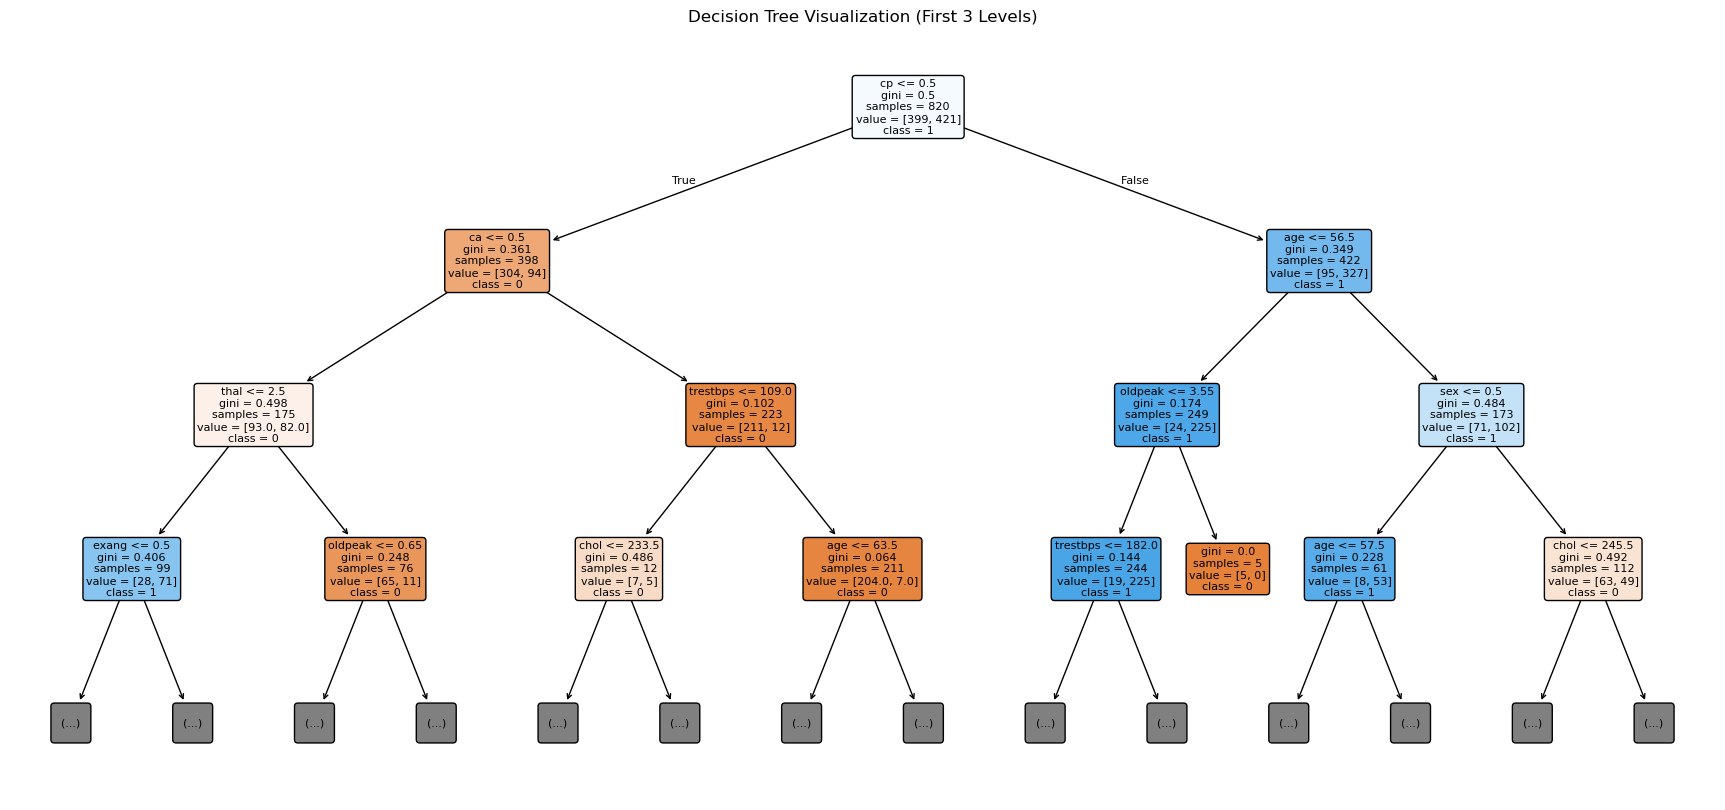

In [11]:
plt.figure(figsize=(22, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [12]:
depth_values = [1, 2, 3, 4, 5, 7, 10, None]

results = []

for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train, model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test, model.predict(X_test)
    )

    results.append({
        "Max Depth": str(depth),
        "Training Accuracy": train_acc,
        "Testing Accuracy": test_acc
    })

depth_results = pd.DataFrame(results)
display(depth_results.round(4))

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.7695,0.7220
1,2,0.7695,0.7220
2,3,0.8451,0.8537
3,4,0.8854,0.8390
4,5,0.9293,0.8732
5,7,0.9915,0.9512
6,10,1.0000,0.9854
7,None,1.0000,0.9854


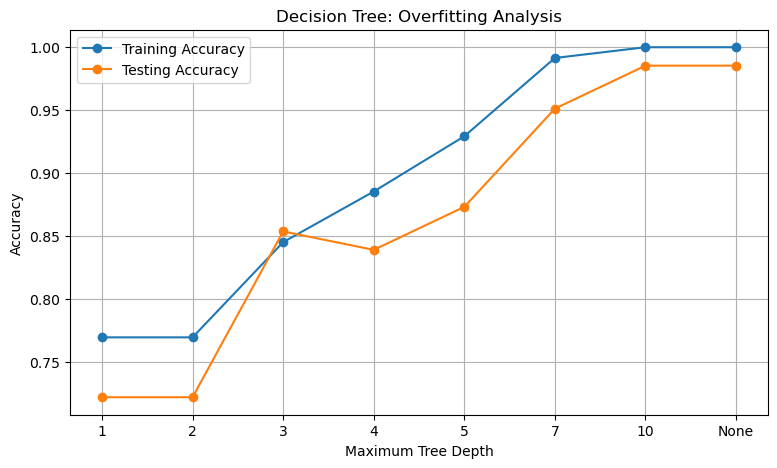

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    depth_results["Max Depth"],
    depth_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results["Max Depth"],
    depth_results["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Overfitting Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print("Random Forest Results")
print("Training Accuracy:", round(rf_train_accuracy, 4))
print("Testing Accuracy:", round(rf_test_accuracy, 4))

Random Forest Results
Training Accuracy: 1.0
Testing Accuracy: 1.0


In [15]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Training Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy
    ],
    "Testing Accuracy": [
        dt_test_accuracy,
        rf_test_accuracy
    ]
})

display(comparison.round(4))

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,1.0,0.9854
1,Random Forest,1.0,1.0000


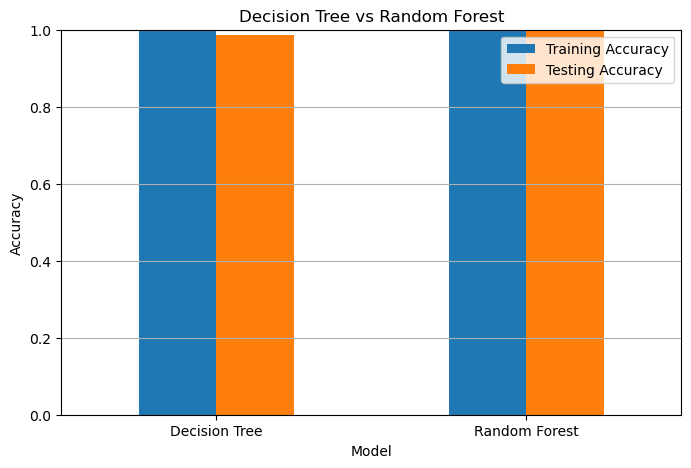

In [16]:
comparison.set_index("Model")[
    ["Training Accuracy", "Testing Accuracy"]
].plot(kind="bar", figsize=(8, 5))

plt.title("Decision Tree vs Random Forest")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(10).round(4))

,Feature,Importance
2,cp,0.1421
7,thalach,0.1173
11,ca,0.1148
9,oldpeak,0.1126
12,thal,0.0959
0,age,0.0913
4,chol,0.0778
8,exang,0.0737
3,trestbps,0.0678
10,slope,0.0487


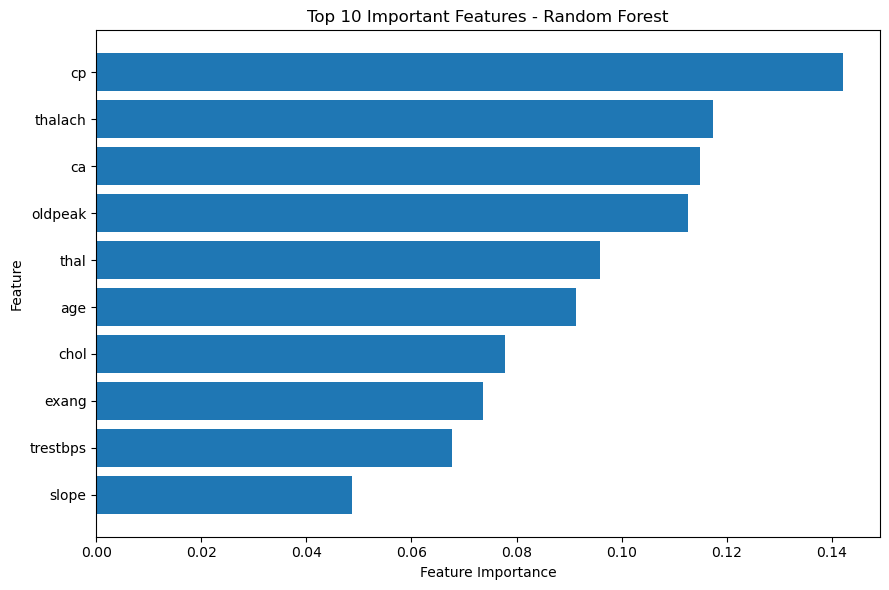

In [18]:
top_features = importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



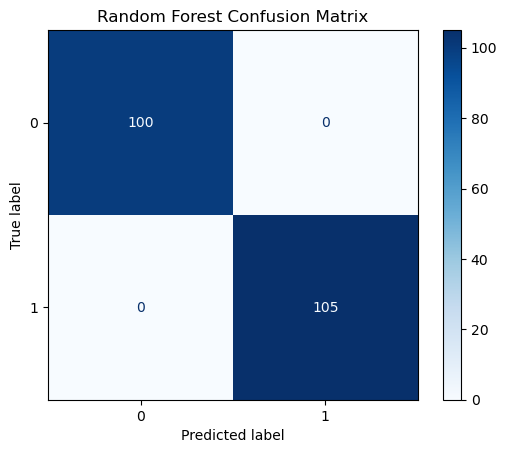

In [19]:
print("Classification Report:")
print(classification_report(y_test, rf_test_pred))

cm = confusion_matrix(y_test, rf_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[str(c) for c in rf_model.classes_]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Decision Tree CV Scores:", np.round(dt_cv_scores, 4))
print("Decision Tree Mean CV Accuracy:", round(dt_cv_scores.mean(), 4))
print("Decision Tree CV Std:", round(dt_cv_scores.std(), 4))

print("\nRandom Forest CV Scores:", np.round(rf_cv_scores, 4))
print("Random Forest Mean CV Accuracy:", round(rf_cv_scores.mean(), 4))
print("Random Forest CV Std:", round(rf_cv_scores.std(), 4))

Decision Tree CV Scores: [1. 1. 1. 1. 1.]
Decision Tree Mean CV Accuracy: 1.0
Decision Tree CV Std: 0.0

Random Forest CV Scores: [1.     1.     1.     0.9805 1.    ]
Random Forest Mean CV Accuracy: 0.9961
Random Forest CV Std: 0.0078
